In [1]:
# Cell 1: Mount Drive and install any extra libraries
from google.colab import drive
drive.mount('/content/drive')

# Standard ML/data libraries (pre-installed in Colab)
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("Libraries loaded ✓")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Libraries loaded ✓


In [2]:
# Cell 2: Find the zip in Drive and extract it
# ── Update this path to match where your file is in Drive ──
ZIP_NAME = "CW2 CW2 Regression Datasets-20260412.zip"
SEARCH_ROOT = "/content/drive/MyDrive"

# Auto-search for the file
matches = []
for root, dirs, files in os.walk(SEARCH_ROOT):
    for f in files:
        if ZIP_NAME in f or "CW2" in f and f.endswith(".zip"):
            matches.append(os.path.join(root, f))

if not matches:
    raise FileNotFoundError(f"Could not find '{ZIP_NAME}' in Drive. "
                            "Check the file name or path above.")

zip_path = matches[0]
print(f"Found: {zip_path}")

# Extract to /content/dataset/
EXTRACT_DIR = "/content/dataset"
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(EXTRACT_DIR)
    print(f"Extracted {len(z.namelist())} files:")
    for name in z.namelist():
        print(f"  {name}")

Found: /content/drive/MyDrive/CW2 CW2 Regression Datasets-20260412.zip
Extracted 2 files:
  NVD_Cybersecurity_Dataset.csv
  rt_iot2022_regression_ready_50_features.csv


In [3]:
# Cell 3 (CORRECTED): Load the IoT dataset — 50 features, correct for assignment
csv_path = "/content/dataset/rt_iot2022_regression_ready_50_features.csv"

df = pd.read_csv(csv_path)
print(f"Dataset: {csv_path.split('/')[-1]}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset: rt_iot2022_regression_ready_50_features.csv
Shape: 123,117 rows × 51 columns


In [4]:
# Cell 4: Structure overview
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\nShape       : {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

print("\n--- Column names & dtypes ---")
print(df.dtypes.to_string())

print("\n--- First 5 rows ---")
df.head()

DATASET OVERVIEW

Shape       : 123,117 rows, 51 columns
Memory usage: 60.9 MB

--- Column names & dtypes ---
id.orig_p                  int64
id.resp_p                  int64
proto                     object
service                   object
fwd_pkts_tot               int64
bwd_pkts_tot               int64
fwd_data_pkts_tot          int64
bwd_data_pkts_tot          int64
fwd_pkts_per_sec         float64
bwd_pkts_per_sec         float64
flow_pkts_per_sec        float64
down_up_ratio            float64
fwd_header_size_tot        int64
fwd_header_size_min        int64
fwd_header_size_max        int64
bwd_header_size_tot        int64
bwd_header_size_min        int64
bwd_header_size_max        int64
flow_FIN_flag_count        int64
flow_SYN_flag_count        int64
flow_RST_flag_count        int64
fwd_PSH_flag_count         int64
bwd_PSH_flag_count         int64
flow_ACK_flag_count        int64
fwd_URG_flag_count         int64
bwd_URG_flag_count         int64
flow_CWR_flag_count        int64

,id.orig_p,id.resp_p,proto,service,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,...,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,flow_duration
0,38667,1883,tcp,mqtt,9,5,3,3,0.281148,0.156193,...,7.714286,11.618477,761.985779,29729182.96,32011597.87,4001449.734,10403073.63,4438.877106,1511693.954,32.011598
1,51143,1883,tcp,mqtt,9,5,3,3,0.282277,0.156821,...,7.714286,11.618477,247.001648,29855277.06,31883584.02,3985448.003,10463455.56,4214.048386,1576435.804,31.883584
2,44761,1883,tcp,mqtt,9,5,3,3,0.280164,0.155647,...,7.428571,11.229866,283.956528,29842149.02,32124053.00,4015506.625,10442377.92,2456.903458,1476048.946,32.124053
3,60893,1883,tcp,mqtt,9,5,3,3,0.281593,0.156440,...,7.428571,11.229866,288.963318,29913774.97,31961063.15,3995132.893,10482528.22,3933.906555,1551892.042,31.961063
4,51087,1883,tcp,mqtt,9,5,3,3,0.282111,0.156728,...,7.714286,11.618477,387.907028,29814704.90,31902361.87,3987795.234,10447019.10,3005.027771,1632083.178,31.902362


In [5]:
# Cell 5: Data quality check
print("=" * 60)
print("DATA QUALITY")
print("=" * 60)

# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

if missing_df.empty:
    print("\nNo missing values found ✓")
else:
    print(f"\nColumns with missing values ({len(missing_df)}):")
    print(missing_df.to_string())

# Duplicates
dupes = df.duplicated().sum()
print(f"\nDuplicate rows: {dupes:,} ({dupes/len(df)*100:.2f}%)")

# Constant columns (no variance — useless for ML)
const_cols = [c for c in df.columns if df[c].nunique() <= 1]
print(f"Constant columns (0 variance): {const_cols if const_cols else 'None ✓'}")

DATA QUALITY

No missing values found ✓

Duplicate rows: 5,202 (4.23%)
Constant columns (0 variance): ['bwd_URG_flag_count']


In [6]:
# Cell 6: Descriptive statistics
print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)

# Numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\nNumeric columns : {len(num_cols)}")
print(f"Categorical cols: {len(cat_cols)}")

print("\n--- Numeric summary ---")
display(df[num_cols].describe().T.round(4))

if cat_cols:
    print("\n--- Categorical value counts (top 5 each) ---")
    for col in cat_cols[:10]:   # limit to first 10 to avoid wall of text
        print(f"\n{col}: {df[col].nunique()} unique values")
        print(df[col].value_counts().head(5).to_string())

DESCRIPTIVE STATISTICS

Numeric columns : 49
Categorical cols: 2

--- Numeric summary ---


,count,mean,std,min,25%,50%,75%,max
id.orig_p,123117.0,3.463926e+04,1.907062e+04,0.0,17702.0000,37221.0000,5.097100e+04,6.553500e+04
id.resp_p,123117.0,1.014305e+03,5.256372e+03,0.0,21.0000,21.0000,2.100000e+01,6.538900e+04
fwd_pkts_tot,123117.0,2.268800e+00,2.233660e+01,0.0,1.0000,1.0000,1.000000e+00,4.345000e+03
bwd_pkts_tot,123117.0,1.909500e+00,3.301830e+01,0.0,1.0000,1.0000,1.000000e+00,1.011200e+04
fwd_data_pkts_tot,123117.0,1.471200e+00,1.963520e+01,0.0,1.0000,1.0000,1.000000e+00,4.345000e+03
bwd_data_pkts_tot,123117.0,8.203000e-01,3.229390e+01,0.0,0.0000,0.0000,0.000000e+00,1.010500e+04
fwd_pkts_per_sec,123117.0,3.518063e+05,3.707645e+05,0.0,74.5435,246723.7647,5.242880e+05,1.048576e+06
bwd_pkts_per_sec,123117.0,3.517620e+05,3.708015e+05,0.0,72.8893,246723.7647,5.242880e+05,1.048576e+06
flow_pkts_per_sec,123117.0,7.035683e+05,7.415634e+05,0.0,149.0871,493447.5294,1.048576e+06,2.097152e+06
down_up_ratio,123117.0,8.546000e-01,3.376000e-01,0.0,1.0000,1.0000,1.000000e+00,6.087900e+00



--- Categorical value counts (top 5 each) ---

proto: 3 unique values
proto
tcp     110427
udp      12633
icmp        57

service: 10 unique values
service
-       102861
dns       9753
mqtt      4132
http      3464
ssl       2663


In [7]:
# Cell 7: Identify likely target column
# ── Change TARGET if the auto-guess is wrong ──
# Common target column names in cybersecurity datasets:
target_candidates = ['label', 'Label', 'attack', 'Attack', 'class',
                     'Class', 'target', 'Target', 'category', 'Category',
                     'attack_type', 'traffic_type', 'Outcome', 'Result']

TARGET = None
for c in target_candidates:
    if c in df.columns:
        TARGET = c
        break

if TARGET is None:
    print("Could not auto-detect target. Last 5 columns:")
    print(df.columns[-5:].tolist())
    print("\nSet TARGET manually, e.g.: TARGET = 'Label'")
else:
    print(f"Target column detected: '{TARGET}'")
    print(f"\nClass distribution:")
    print(df[TARGET].value_counts())
    print(f"\nClass balance (%):")
    print((df[TARGET].value_counts(normalize=True)*100).round(2))

Could not auto-detect target. Last 5 columns:
['fwd_iat.avg', 'fwd_iat.std', 'bwd_iat.min', 'bwd_iat.max', 'flow_duration']

Set TARGET manually, e.g.: TARGET = 'Label'


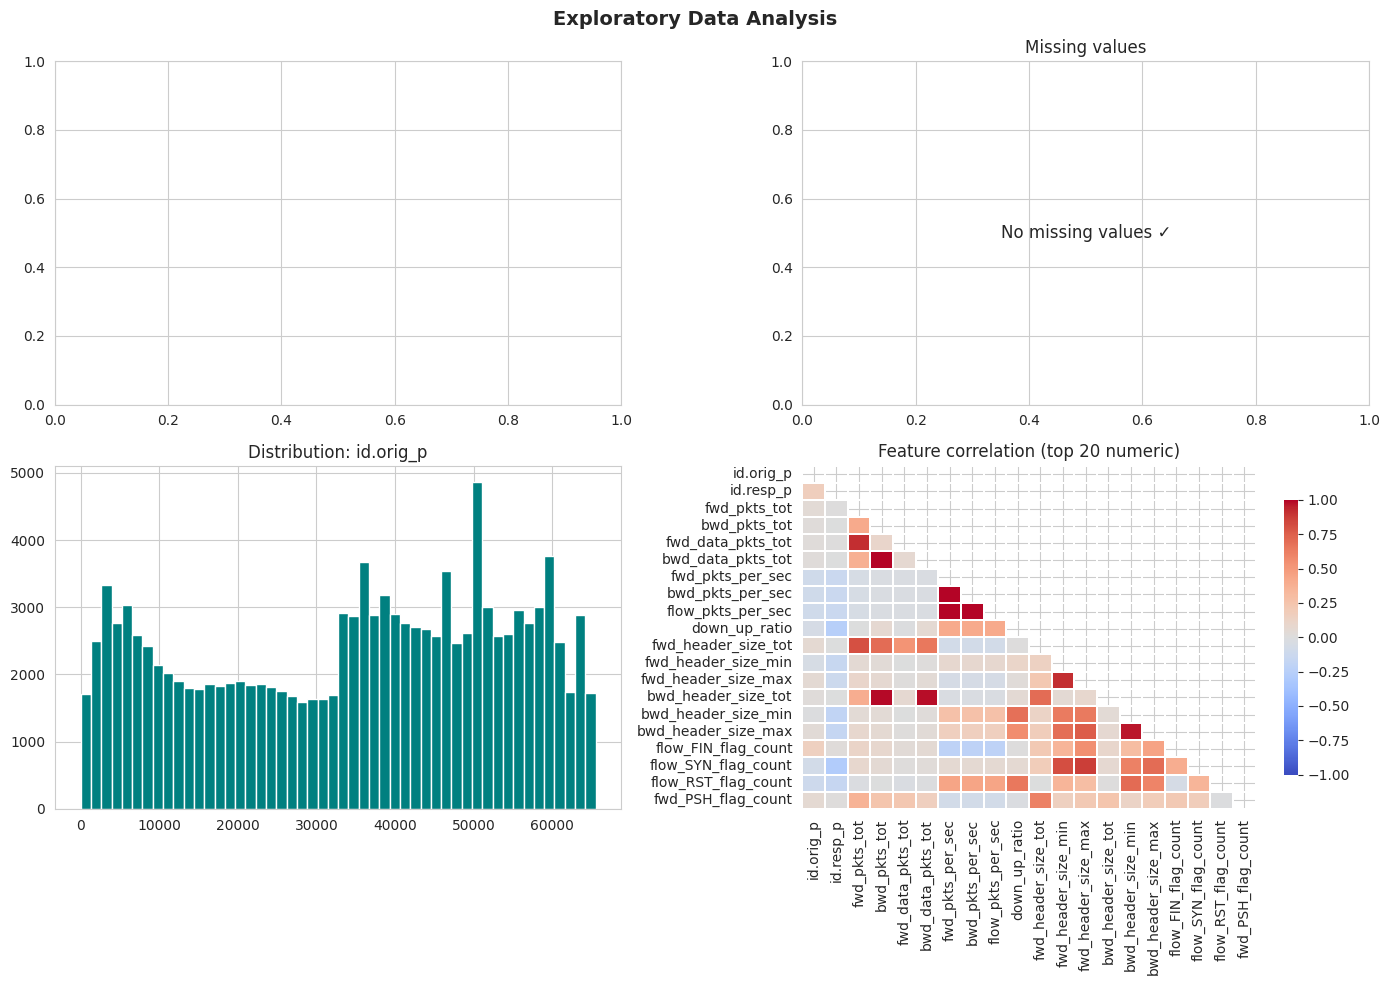

Plot saved as eda_overview.png


In [8]:
# Cell 8: Key visualisations for the presentation
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Exploratory Data Analysis", fontsize=14, fontweight='bold')

# Plot 1: Class distribution
if TARGET:
    top_classes = df[TARGET].value_counts().head(15)
    top_classes.plot(kind='bar', ax=axes[0,0], color='steelblue', edgecolor='white')
    axes[0,0].set_title("Class distribution")
    axes[0,0].set_xlabel("")
    axes[0,0].tick_params(axis='x', rotation=45)

# Plot 2: Missing values heatmap (if any)
if missing_df.empty:
    axes[0,1].text(0.5, 0.5, "No missing values ✓",
                   ha='center', va='center', fontsize=12,
                   transform=axes[0,1].transAxes)
    axes[0,1].set_title("Missing values")
else:
    missing_df['Missing %'].plot(kind='barh', ax=axes[0,1], color='coral')
    axes[0,1].set_title("Missing values (%)")

# Plot 3: Distribution of first numeric feature
sample_col = num_cols[0] if num_cols else None
if sample_col:
    axes[1,0].hist(df[sample_col].dropna(), bins=50, color='teal', edgecolor='white')
    axes[1,0].set_title(f"Distribution: {sample_col}")

# Plot 4: Correlation heatmap (top 20 numeric features)
if len(num_cols) > 1:
    top20 = num_cols[:20]
    corr = df[top20].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, ax=axes[1,1], cmap='coolwarm',
                center=0, vmin=-1, vmax=1, linewidths=0.3,
                cbar_kws={"shrink": 0.8})
    axes[1,1].set_title("Feature correlation (top 20 numeric)")

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as eda_overview.png")

In [9]:
# Cell 10: Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

df_model = df.copy()

# 1. Drop rows where target is 0 or NaN (uninformative)
df_model = df_model[df_model['flow_duration'] > 0].dropna(subset=['flow_duration'])
print(f"Rows after cleaning: {len(df_model):,}")

# 2. Encode categorical columns
le_proto   = LabelEncoder()
le_service = LabelEncoder()
df_model['proto']   = le_proto.fit_transform(df_model['proto'].astype(str))
df_model['service'] = le_service.fit_transform(df_model['service'].astype(str))
print(f"proto classes   : {list(le_proto.classes_)}")
print(f"service classes : {list(le_service.classes_)}")

# 3. Handle missing values (fill with median)
df_model.fillna(df_model.median(numeric_only=True), inplace=True)

# 4. Log-transform the target (heavy right skew)
df_model['log_flow_duration'] = np.log1p(df_model['flow_duration'])

# 5. Features and target
TARGET_LOG = 'log_flow_duration'
DROP_COLS  = ['flow_duration', TARGET_LOG]
FEATURES   = [c for c in df_model.columns if c not in DROP_COLS]

X = df_model[FEATURES].values
y = df_model[TARGET_LOG].values

print(f"\nFeature matrix : {X.shape}")
print(f"Target (log)   : min={y.min():.3f}, max={y.max():.3f}, mean={y.mean():.3f}")

# 6. Train/test split (80/20, stratified not needed for regression)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f"\nTrain set: {X_train.shape[0]:,} rows")
print(f"Test  set: {X_test.shape[0]:,} rows")

# 7. Scale features (important for Linear Regression and SVR)
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("\nPreprocessing complete ✓")

Rows after cleaning: 107,136
proto classes   : ['icmp', 'tcp', 'udp']
service classes : ['-', 'dhcp', 'dns', 'http', 'irc', 'mqtt', 'ntp', 'ssh', 'ssl']

Feature matrix : (107136, 50)
Target (log)   : min=0.000, max=9.986, mean=0.235

Train set: 85,708 rows
Test  set: 21,428 rows

Preprocessing complete ✓


In [10]:
# Cell 11: Shared evaluation function
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

results = {}   # store all model results here

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, scaled=False):
    """Train, predict and evaluate a regression model."""
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    y_pred = model.predict(X_te)

    # Back-transform from log space for interpretable metrics
    y_te_orig   = np.expm1(y_te)
    y_pred_orig = np.expm1(y_pred)

    mae  = mean_absolute_error(y_te_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_te_orig, y_pred_orig))
    r2   = r2_score(y_te, y_pred)          # R² on log scale (better for skewed data)
    r2_raw = r2_score(y_te_orig, y_pred_orig)

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'MAE': mae,
        'RMSE': rmse,
        'R2_log': r2,
        'R2_raw': r2_raw,
        'train_time': train_time
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  MAE        : {mae:.4f} seconds")
    print(f"  RMSE       : {rmse:.4f} seconds")
    print(f"  R² (log)   : {r2:.4f}")
    print(f"  R² (raw)   : {r2_raw:.4f}")
    print(f"  Train time : {train_time:.2f}s")
    return model

print("Evaluation helper ready ✓")

Evaluation helper ready ✓


In [11]:
# Cell 12: Model 1 — Linear Regression (baseline, uses scaled data)
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
evaluate_model("Linear Regression", lr,
               X_train_sc, y_train,
               X_test_sc,  y_test)


  Linear Regression
  MAE        : 628.4925 seconds
  RMSE       : 75657.9365 seconds
  R² (log)   : 0.9092
  R² (raw)   : -255784.5857
  Train time : 0.58s


LinearRegression()

In [12]:
# Cell 13: Model 2 — Random Forest Regressor (no scaling needed)
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)
evaluate_model("Random Forest", rf,
               X_train, y_train,
               X_test,  y_test)


  Random Forest
  MAE        : 0.6580 seconds
  RMSE       : 84.6617 seconds
  R² (log)   : 0.9982
  R² (raw)   : 0.6797
  Train time : 103.04s


RandomForestRegressor(max_depth=15, min_samples_leaf=5, n_jobs=-1,
                      random_state=42)

In [13]:
# Cell 14: Model 3 — Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=42
)
evaluate_model("Gradient Boosting", gb,
               X_train, y_train,
               X_test,  y_test)


  Gradient Boosting
  MAE        : 0.3265 seconds
  RMSE       : 41.4757 seconds
  R² (log)   : 0.9998
  R² (raw)   : 0.9231
  Train time : 116.41s


GradientBoostingRegressor(max_depth=5, min_samples_leaf=5, n_estimators=200,
                          random_state=42, subsample=0.8)

In [14]:
# Cell 15: Model 4 — Support Vector Regression (sampled for speed)
from sklearn.svm import SVR

# Sample 20k rows — SVR is O(n²), too slow on 100k+
SAMPLE = 20_000
idx = np.random.RandomState(42).choice(len(X_train_sc), SAMPLE, replace=False)
X_svr_tr = X_train_sc[idx]
y_svr_tr = y_train[idx]

svr = SVR(kernel='rbf', C=10, gamma='scale', epsilon=0.1)
evaluate_model("SVR (sampled 20k)", svr,
               X_svr_tr, y_svr_tr,
               X_test_sc, y_test)


  SVR (sampled 20k)
  MAE        : 1.6804 seconds
  RMSE       : 148.7433 seconds
  R² (log)   : 0.9750
  R² (raw)   : 0.0114
  Train time : 2.09s


SVR(C=10)

In [15]:
# Cell 16: Summary comparison table
summary = pd.DataFrame({
    name: {
        'MAE':        f"{v['MAE']:.4f}",
        'RMSE':       f"{v['RMSE']:.4f}",
        'R² (log)':   f"{v['R2_log']:.4f}",
        'R² (raw)':   f"{v['R2_raw']:.4f}",
        'Train time': f"{v['train_time']:.2f}s"
    }
    for name, v in results.items()
}).T

print("=" * 65)
print("MODEL COMPARISON — RT-IoT2022 | Target: flow_duration")
print("=" * 65)
print(summary.to_string())
print("=" * 65)
print("\nBest R² (log):", max(results, key=lambda k: results[k]['R2_log']))

MODEL COMPARISON — RT-IoT2022 | Target: flow_duration
                        MAE        RMSE R² (log)      R² (raw) Train time
Linear Regression  628.4925  75657.9365   0.9092  -255784.5857      0.58s
Random Forest        0.6580     84.6617   0.9982        0.6797    103.04s
Gradient Boosting    0.3265     41.4757   0.9998        0.9231    116.41s
SVR (sampled 20k)    1.6804    148.7433   0.9750        0.0114      2.09s

Best R² (log): Gradient Boosting


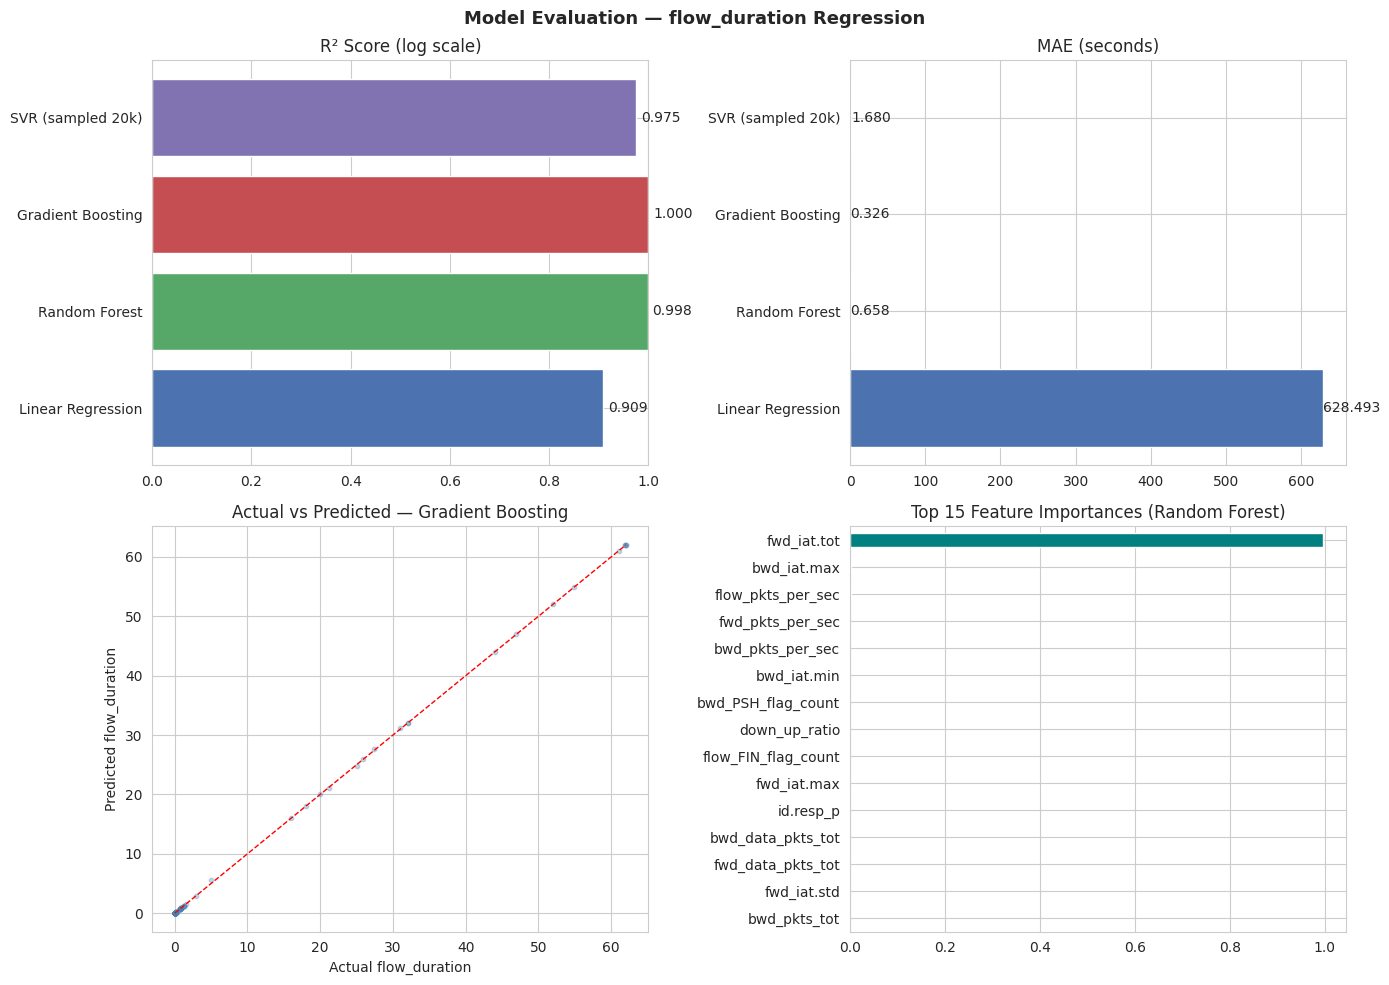

Saved: model_results.png


In [16]:
# Cell 17: Visualisations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Model Evaluation — flow_duration Regression", fontsize=13, fontweight='bold')

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
names  = list(results.keys())

# Plot 1: R² comparison
r2_vals = [results[n]['R2_log'] for n in names]
axes[0,0].barh(names, r2_vals, color=colors)
axes[0,0].set_title("R² Score (log scale)")
axes[0,0].set_xlim(0, 1)
axes[0,0].axvline(0, color='gray', linewidth=0.5)
for i, v in enumerate(r2_vals):
    axes[0,0].text(v + 0.01, i, f"{v:.3f}", va='center', fontsize=10)

# Plot 2: MAE comparison
mae_vals = [results[n]['MAE'] for n in names]
axes[0,1].barh(names, mae_vals, color=colors)
axes[0,1].set_title("MAE (seconds)")
for i, v in enumerate(mae_vals):
    axes[0,1].text(v + 0.01, i, f"{v:.3f}", va='center', fontsize=10)

# Plot 3: Actual vs Predicted (best model)
best = max(results, key=lambda k: results[k]['R2_log'])
y_pred_best = results[best]['y_pred']
y_actual = np.expm1(y_test[:500])
y_pred_plot = np.expm1(y_pred_best[:500])
axes[1,0].scatter(y_actual, y_pred_plot, alpha=0.3, s=10, color='steelblue')
lim = max(y_actual.max(), y_pred_plot.max())
axes[1,0].plot([0, lim], [0, lim], 'r--', linewidth=1)
axes[1,0].set_xlabel("Actual flow_duration")
axes[1,0].set_ylabel("Predicted flow_duration")
axes[1,0].set_title(f"Actual vs Predicted — {best}")

# Plot 4: Feature importance (Random Forest)
if 'Random Forest' in results:
    importances = results['Random Forest']['model'].feature_importances_
    feat_imp = pd.Series(importances, index=FEATURES).nlargest(15)
    feat_imp.plot(kind='barh', ax=axes[1,1], color='teal')
    axes[1,1].set_title("Top 15 Feature Importances (Random Forest)")
    axes[1,1].invert_yaxis()

plt.tight_layout()
plt.savefig("model_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_results.png")

In [17]:
# Cell 19: Cross-validation for robustness
from sklearn.model_selection import cross_val_score

print("5-Fold Cross-Validation R² scores (log scale)\n")

models_cv = {
    'Linear Regression' : (lr, X_train_sc),
    'Random Forest'     : (rf, X_train),
    'Gradient Boosting' : (gb, X_train),
}

for name, (model, X_cv) in models_cv.items():
    scores = cross_val_score(model, X_cv, y_train,
                             cv=5, scoring='r2', n_jobs=-1)
    print(f"{name}")
    print(f"  Scores : {scores.round(4)}")
    print(f"  Mean   : {scores.mean():.4f} (+/- {scores.std():.4f})\n")

5-Fold Cross-Validation R² scores (log scale)

Linear Regression
  Scores : [0.6998 0.8024 0.127  0.9036 0.8915]
  Mean   : 0.6849 (+/- 0.2884)

Random Forest
  Scores : [0.9996 0.9987 0.9989 0.9989 0.9983]
  Mean   : 0.9989 (+/- 0.0004)

Gradient Boosting
  Scores : [0.9999 0.9998 0.9998 0.9999 0.9997]
  Mean   : 0.9998 (+/- 0.0001)



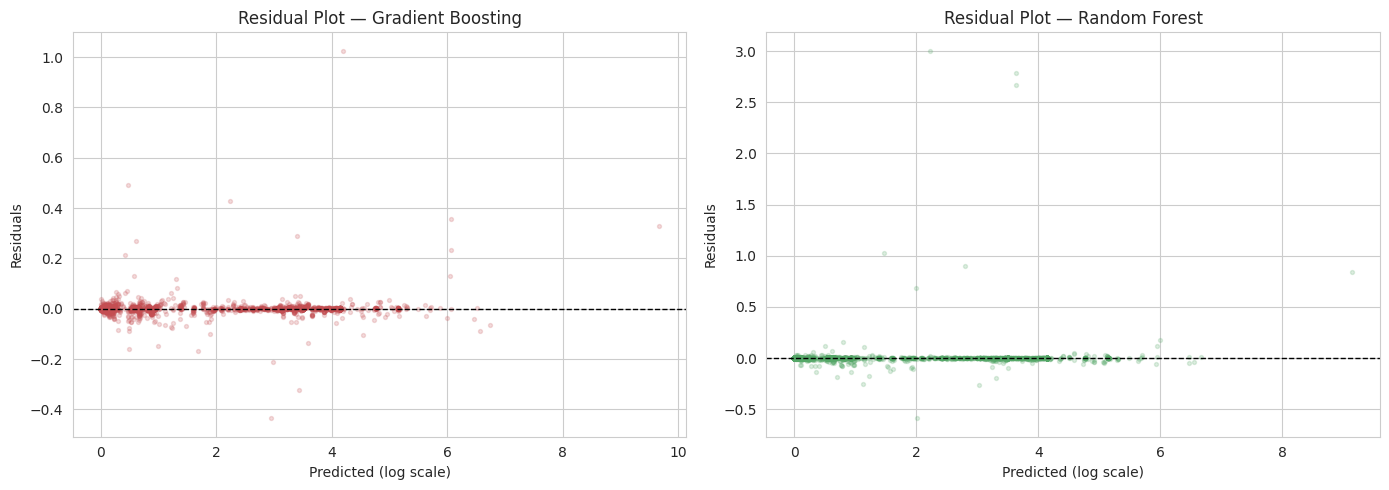

Saved: residual_plots.png


In [18]:
# Cell 20: Residual plot (good for presentation)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, color in zip(axes,
                            ['Gradient Boosting', 'Random Forest'],
                            ['#C44E52', '#55A868']):
    y_pred = results[name]['y_pred']
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.2, s=8, color=color)
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.set_xlabel("Predicted (log scale)")
    ax.set_ylabel("Residuals")
    ax.set_title(f"Residual Plot — {name}")

plt.tight_layout()
plt.savefig("residual_plots.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: residual_plots.png")

In [19]:
# Save all models as .pkl (pickle) files to Google Drive
import pickle, os

SAVE_DIR = "/content/drive/MyDrive/CW2_Models"
os.makedirs(SAVE_DIR, exist_ok=True)

models_to_save = {
    'linear_regression' : results['Linear Regression']['model'],
    'random_forest'     : results['Random Forest']['model'],
    'gradient_boosting' : results['Gradient Boosting']['model'],
    'svr'               : results['SVR (sampled 20k)']['model'],
    'scaler'            : scaler,
    'label_encoder_proto'   : le_proto,
    'label_encoder_service' : le_service,
}

for name, obj in models_to_save.items():
    path = f"{SAVE_DIR}/{name}.pkl"
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    size = os.path.getsize(path) / 1e6
    print(f"Saved: {name}.pkl  ({size:.1f} MB)")

print(f"\nAll files saved to: {SAVE_DIR}")

Saved: linear_regression.pkl  (0.0 MB)
Saved: random_forest.pkl  (17.1 MB)
Saved: gradient_boosting.pkl  (0.4 MB)
Saved: svr.pkl  (0.2 MB)
Saved: scaler.pkl  (0.0 MB)
Saved: label_encoder_proto.pkl  (0.0 MB)
Saved: label_encoder_service.pkl  (0.0 MB)

All files saved to: /content/drive/MyDrive/CW2_Models
